In [1]:
import os
import sys
from glob import glob

module_path = os.path.abspath(os.path.join('../module/'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from prostate_recurrence.data_exploration import stitching

In [3]:
import pandas as pd

## define path to the tile level features

In [4]:
path_to_tiles_raw_psr = \
"/Volumes/proj-sahai-tme-ml/working/processed_data/pre_processed_data/clinical/prostate/chiip_cohort/slide/C001021_B05/tile_size_1024/whole_slide/PSR/raw_tiling/"
path_to_tiles_features = \
"/Volumes/proj-sahai-tme-ml/working/processed_data/feature_engineering/clinical/prostate/chiip_cohort/slide/C001021_B05/tile_size_1024/whole_slide/PSR/deconvolutions/psr/inverted_grayscale/tile_level_features/"
NROW = 15
NCOL = 15
TILE_SIZE =1024

## define path to save stitching and overlay

In [5]:
subdir_feature_heatmap_stitching_and_overlay = "outputs_feature_heatmap_stitching_and_overlay"
path_to_save_stitching_and_overlay = os.path.join(
    '../../../2021m08__stitching_overlay/', 
    subdir_feature_heatmap_stitching_and_overlay
)
os.makedirs(
    path_to_save_stitching_and_overlay, 
    exist_ok=True
)
os.chmod(path_to_save_stitching_and_overlay, mode=0o775)

## stitch tile-level feature heat maps

In [6]:
which_tif_files = glob(
    os.path.join(
        path_to_tiles_features,
        "image_tile_00003_00005_psr",
        "*tif"
    )
)

In [7]:
file_patterns = [
    which_tif.split('/')[-1] for which_tif in which_tif_files
]


In [8]:
file_patterns_ready = []

In [9]:
file_patterns_skip = [
    file_pattern for file_pattern in file_patterns
    if '_cm' in file_pattern
]

In [10]:
for file_pattern in file_patterns[:1]:
    
    if file_pattern in file_patterns_skip:
        print(f"skipping feature : {file_pattern}")
        continue      
        
    if file_pattern in file_patterns_ready:
        print(f"already processed feature : {file_pattern}")
        continue      
        
    print(f"> processing feature = {file_pattern}")
    file_paths = glob(
        os.path.join(path_to_tiles_features, f"image_tile_*_psr/{file_pattern}")
    )
    
    save_path = os.path.join(
        path_to_save_stitching_and_overlay,
        f"{file_pattern}_stitched_wsi.jpg"
    )
    
    
    if glob(save_path):
        print("this feature has already been analysed! continue to next ...")
        continue
    
    print(f"... saving output to {save_path}")
    stitching.reconstruct_whole_slide(
        file_paths=file_paths,
        position_in_path_has_tile_row_col=-2,
        save_path=save_path,
        nrow=NROW,
        ncol=NCOL,
        dim=(1024, 1024, 3)
    )
    
    file_patterns_ready.append(file_pattern)

> processing feature = curvature_Y_derivative.tif
this feature has already been analysed! continue to next ...


## overlay tile-level single-value feature on whole slide raw

In [11]:
file_pattern_overlay = "features_out.csv"

In [12]:
file_paths_features = glob(
    os.path.join(
        path_to_tiles_features, 
        f"image_tile_*_psr/{file_pattern_overlay}"
    )
)

In [13]:
row_col_strings = [
    '_'.join(
        [
            file_path_feature.split('/')[-2].split('_')[2],
            file_path_feature.split('/')[-2].split('_')[3],
        ]
    ) for file_path_feature in file_paths_features
]

### whole slide raw psr

In [14]:
file_paths_all = glob(os.path.join(
    path_to_tiles_raw_psr,
    "image_tile*.tif"
))

file_paths = [
    file_path for file_path in file_paths_all
    if '_'.join(
        [
            file_path.split('/')[-1].split('_')[2],
            file_path.split('/')[-1].split('_')[3].split('.')[0]
        ]
    ) in row_col_strings
]



In [15]:
save_path = os.path.join(
    path_to_save_stitching_and_overlay,
    f"raw_PSR_stitched_wsi.jpg"
)
raw_image = stitching.reconstruct_whole_slide(
    file_paths=file_paths,
    position_in_path_has_tile_row_col=-1,
    save_path=save_path,
    nrow=NROW,
    ncol=NCOL,
    dim=(1024, 1024, 3)
)

100%|██████████| 32/32 [00:09<00:00,  3.22it/s]


### whole slide overlay features

In [16]:
features_all = pd.DataFrame()
for file_path_feature in file_paths_features:
    subdir = file_path_feature.split('/')[-2]
    features = pd.read_csv(file_path_feature, header = None, names = ['feature', 'value'])
    features['tile'] = subdir
    features_all = features_all.append(features)

> mapping feature : HDM


100%|██████████| 32/32 [00:00<00:00, 443.88it/s]


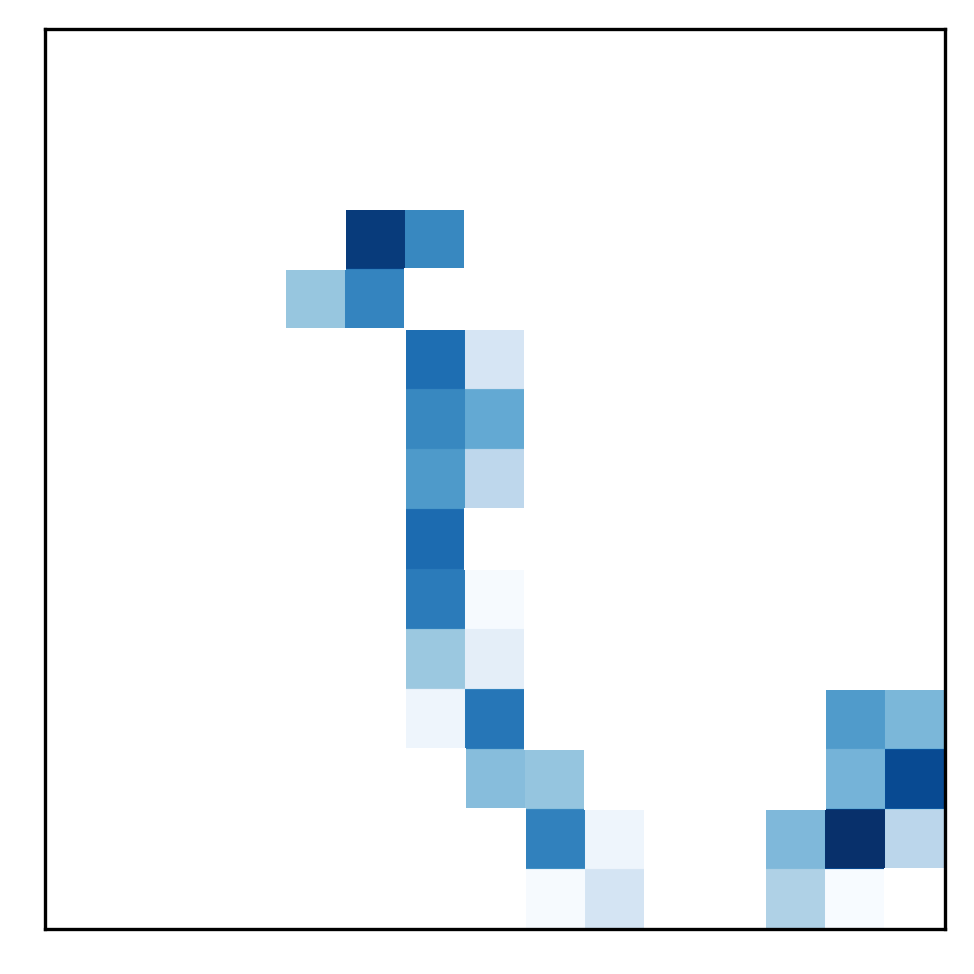

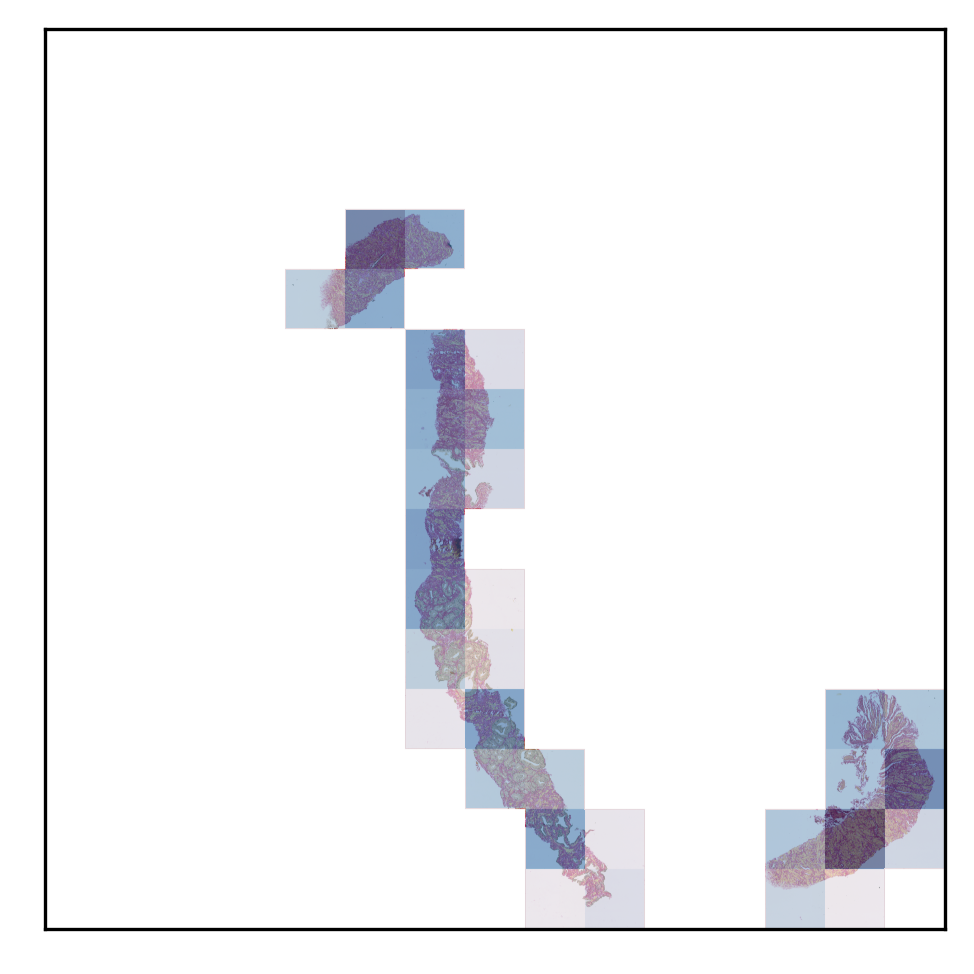

In [17]:
for feature_to_map in features_all.feature.unique()[:1]:
    print(f"> mapping feature : {feature_to_map}")
    save_path = os.path.join(
        path_to_save_stitching_and_overlay,
        f"spatial_mapping_{feature_to_map}.jpg"
    )
    mask = stitching.visualise_overlay(
        raw_image=raw_image,
        file_paths=file_paths_features,
        position_in_path_has_tile_row_col=-2,
        features_all=features_all,
        feature_to_map=feature_to_map,
        save_path=save_path,
        nrow=NROW,
        ncol=NCOL,
        size=1024
    )